In [175]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import sph_harm_y, genlaguerre
import math

Note: Change the quantum number values and **run all cells**. The graphs will all be updated at once

In [176]:
#Define your n, l and m values: 

n_value = 3
l_value = 0
m_value = 0

# Radial Distribution Function against distance r from the nucleus 

- Maxima of RDF: highest probability of finding an electron at that distance r  

87
The distance from the nucleus with the highest probability of finding an electron is 13.115577889447234


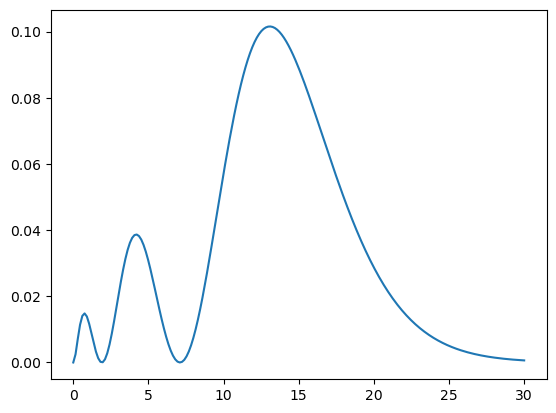

In [177]:
a = 1  # Bohr radius
r = np.linspace(0, 30, 200)

#Defining a function that computes the radial part of the wavefunction
def radial(n, l, r):
    rho = 2 * r / (n * a)
    norm = np.sqrt((2 / (n * a))**3 * math.factorial(n - l - 1) / (2 * n * math.factorial(n + l)))
    laguerre = genlaguerre(n - l - 1, 2 * l + 1)(rho)
    R = norm * np.exp(-rho / 2) * rho**l * laguerre
    return R

#Computing rdf 
radial_part = radial(n_value, l_value, r)
rdf = (r**2) * (np.abs(radial_part)**2)

#Finding the index that contains the rdf maxima, and finding the associated distance r
max_rdf_index = np.argmax(rdf)
print(max_rdf_index)
print(f"The distance from the nucleus with the highest probability of finding an electron is {r[max_rdf_index]}")

#Plotting a graph of rdf against r
plt.plot(r, rdf)
plt.show()

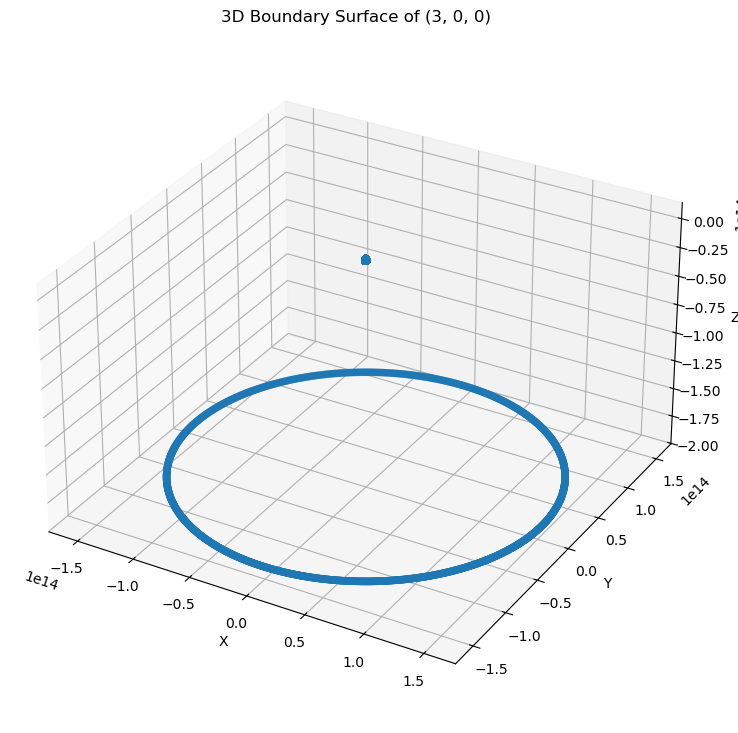

In [178]:
a = 1  # Bohr radius

#Rounding up the radius that corresponds to the rdf maxima and using it to plot the 3D boundary surface
r_random = np.random.randn(2000) * 10
theta, phi = np.meshgrid(np.linspace(0, np.pi, 2000), np.linspace(0, 2 * np.pi, 2000))

#Defining a function that computes the angular part of the wavefunction
def angular(l,m):
    Y = sph_harm_y(l, m, theta, phi)
    if m == 0:
        return Y
    elif m > 0:
        Y_real = Y.real
        return Y_real
    else:
        Y_imag = Y.imag
        return Y_imag

#Computing the radial and angular part for the quantum numbers provided, at r_max 
radial_part = radial(n_value, l_value, r_random)
angular_part = angular(l_value,m_value)
wavefunction = radial_part * np.abs(angular_part)

#Converting from spherical to cartesian coordinates
x = radial_part * np.sin(theta) * np.cos(phi)
y = radial_part * np.sin(theta) * np.sin(phi)
z = radial_part * np.cos(theta)

X, Y, Z = x * wavefunction, y * wavefunction, z * wavefunction

#Plotting the 3D boundary surface 
fig = plt.figure(figsize=(15,9))
ax = fig.add_subplot(1,1,1, projection = '3d')
ax.scatter(X,Y,Z)
ax.set_aspect('equal')
ax.set(xlabel='X', ylabel='Y', zlabel='Z')
ax.set_title(f'3D Boundary Surface of ({n_value}, {l_value}, {m_value})')
plt.show()


# 3D Boundary Surface Plot

- Not sure if my approach is correct tho

14


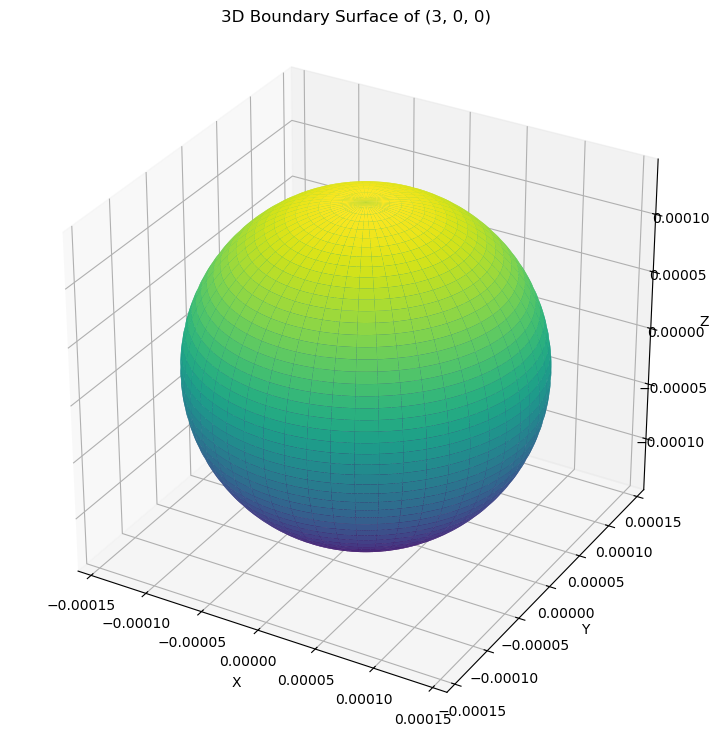

In [179]:
a = 1  # Bohr radius

#Rounding up the radius that corresponds to the rdf maxima and using it to plot the 3D boundary surface
r_max = math.ceil(r[max_rdf_index])
print(r_max)
theta, phi = np.meshgrid(np.linspace(0, np.pi, 200), np.linspace(0, 2 * np.pi, 200))

#Defining a function that computes the angular part of the wavefunction
def angular(l,m):
    Y = sph_harm_y(l, m, theta, phi)
    if m == 0:
        return Y
    elif m > 0:
        Y_real = Y.real
        return Y_real
    else:
        Y_imag = Y.imag
        return Y_imag

#Computing the radial and angular part for the quantum numbers provided, at r_max 
radial_part = radial(n_value, l_value, r_max)
angular_part = angular(l_value,m_value)
wavefunction = radial_part * np.abs(angular_part)

#Converting from spherical to cartesian coordinates
x = radial_part * np.sin(theta) * np.cos(phi)
y = radial_part * np.sin(theta) * np.sin(phi)
z = radial_part * np.cos(theta)

X, Y, Z = x * wavefunction, y * wavefunction, z * wavefunction

#Plotting the 3D boundary surface 
fig = plt.figure(figsize=(15,9))
ax = fig.add_subplot(1,1,1, projection = '3d')
ax.plot_surface(X,Y,Z,cmap='viridis')
ax.set_aspect('equal')
ax.set(xlabel='X', ylabel='Y', zlabel='Z')
ax.set_title(f'3D Boundary Surface of ({n_value}, {l_value}, {m_value})')
plt.show()


# Electron Density Plot

C:\Users\natha\AppData\Local\Temp\ipykernel_34764\3644037679.py:32: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X,Z,e_density, cmap='magma')


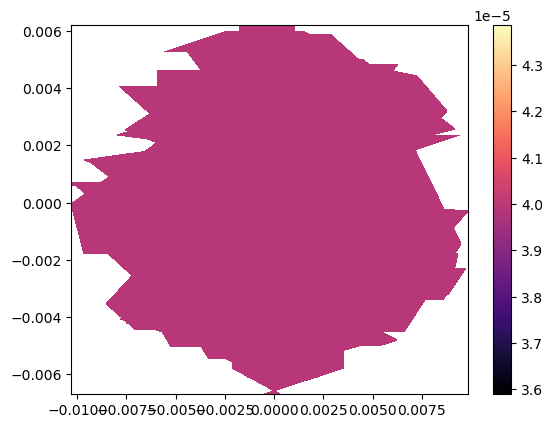

In [ ]:
#Defining with spherical coords -> Doesnt work 

a = 1  # Bohr radius


r_range = np.random.randn(200) * 10
theta, phi = np.meshgrid(np.random.randn(200) * np.pi, np.random.randn(200) *2  * np.pi)

def angular(l,m):
    Y = sph_harm_y(l, m, theta, phi)
    if m == 0:
        return Y
    elif m > 0:
        Y_real = Y.real
        return Y_real
    else:
        Y_imag = Y.imag
        return Y_imag


radial_part = radial(n_value, l_value, r_max)
angular_part = angular(l_value,m_value)
wavefunction = radial_part * np.abs(angular_part)

x = np.sin(theta) * np.cos(phi)
y = np.sin(theta) * np.sin(phi)
z = np.cos(theta)

X, Y, Z = x * wavefunction, y * wavefunction, z * wavefunction

e_density = np.abs(wavefunction)**2

mask = e_density < 0
plt.pcolormesh(X,Z,e_density, cmap='magma')
plt.colorbar()
plt.show()


C:\Users\natha\AppData\Local\Temp\ipykernel_34764\504809915.py:32: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X,Z,e_density, cmap='magma')


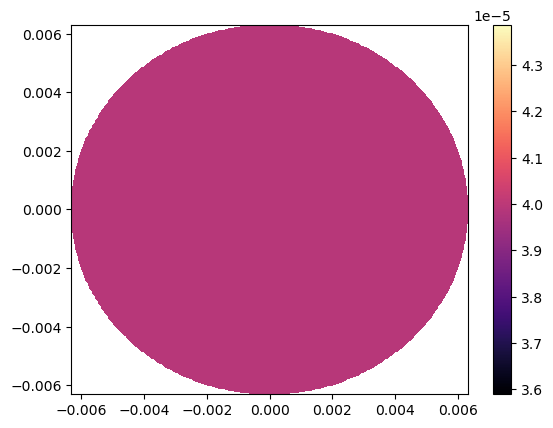

In [ ]:
#Defining with spherical coords -> Doesnt work 

a = 1  # Bohr radius

r_max = math.ceil(r[max_rdf_index])
r_range = np.linspace(0, r_max, 200)
theta, phi = np.meshgrid(np.linspace(0, np.pi, 200), np.linspace(0, 2 * np.pi, 200))

def angular(l,m):
    Y = sph_harm_y(l, m, theta, phi)
    if m == 0:
        return Y
    elif m > 0:
        Y_real = Y.real
        return Y_real
    else:
        Y_imag = Y.imag
        return Y_imag


radial_part = radial(n_value, l_value, r_max)
angular_part = angular(l_value,m_value)
wavefunction = radial_part * np.abs(angular_part)

x = np.sin(theta) * np.cos(phi)
y = np.sin(theta) * np.sin(phi)
z = np.cos(theta)

X, Y, Z = x * wavefunction, y * wavefunction, z * wavefunction

e_density = np.abs(wavefunction)**2
plt.pcolormesh(X,Z,e_density, cmap='magma')
plt.colorbar()
plt.show()


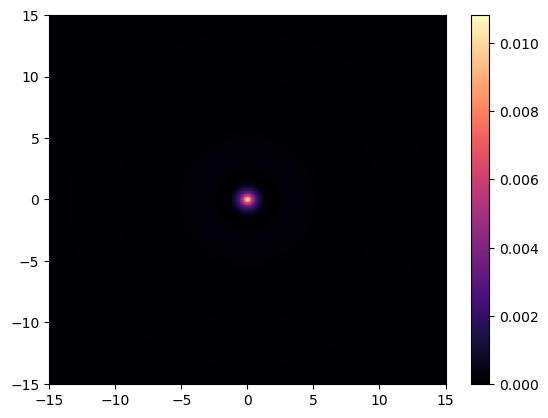

In [181]:
#Defining with cartesian coords 

a = 1  # Bohr radius

x = np.linspace(-5*n_value,5*n_value,500)
z = np.linspace(-5*n_value,5*n_value,500)

X,Z = np.meshgrid(x,z)
Y = 0

r = np.sqrt(X**2+Y**2+Z**2)
theta = np.arccos(Z/r)
phi = np.arctan2(Y,X)

def radial(n, l, r):
    rho = 2 * r / (n * a)
    norm = np.sqrt((2 / (n * a))**3 * math.factorial(n - l - 1) / (2 * n * math.factorial(n + l)))
    laguerre = genlaguerre(n - l - 1, 2 * l + 1)(rho)
    R = norm * np.exp(-rho / 2) * rho**l * laguerre
    return R
def angular(l,m):
    Y = sph_harm_y(l, m, theta, phi)
    if m == 0:
        return Y
    elif m > 0:
        Y_real = Y.real
        return Y_real
    else:
        Y_imag = Y.imag
        return Y_imag

radial_part = radial(n_value, l_value, r)
angular_part = angular(l_value,m_value)
wavefunction = np.abs(radial_part * angular_part)
e_density = np.abs(wavefunction)**2

plt.pcolormesh(X,Z,e_density, cmap='magma')
plt.colorbar()
plt.show()


C:\Users\natha\AppData\Local\Temp\ipykernel_34764\381315166.py:40: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(X,Y,Z,cmap='viridis')


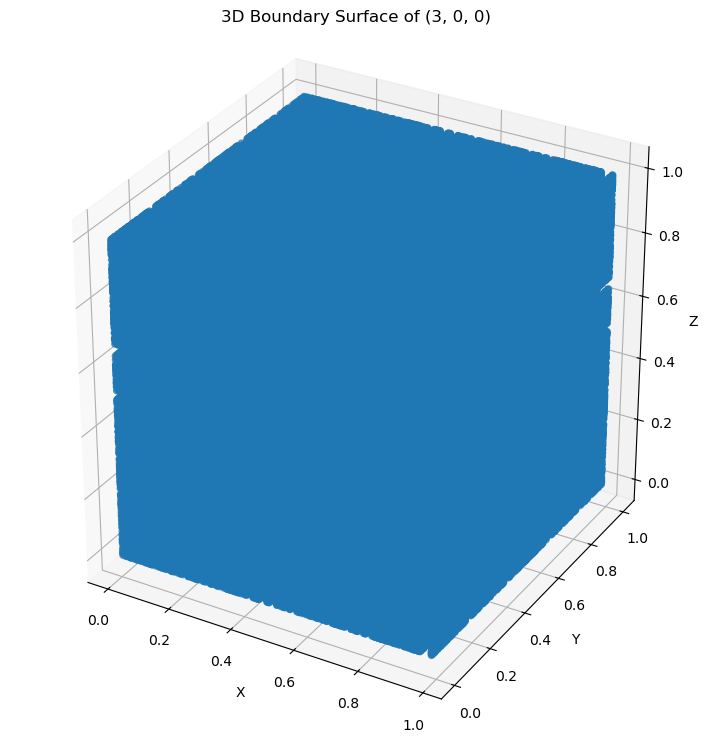

In [186]:
#Defining with cartesian coords 

a = 1  # Bohr radius

x = np.random.rand(200)
y = np.random.rand(200)
z = np.random.rand(200)

X,Y, Z = np.meshgrid(x, y, z)


r = np.sqrt(X**2+Y**2+Z**2)
theta = np.arccos(Z/r)
phi = np.arctan2(Y,X)

def radial(n, l, r):
    rho = 2 * r / (n * a)
    norm = np.sqrt((2 / (n * a))**3 * math.factorial(n - l - 1) / (2 * n * math.factorial(n + l)))
    laguerre = genlaguerre(n - l - 1, 2 * l + 1)(rho)
    R = norm * np.exp(-rho / 2) * rho**l * laguerre
    return R
def angular(l,m):
    Y = sph_harm_y(l, m, theta, phi)
    if m == 0:
        return Y
    elif m > 0:
        Y_real = Y.real
        return Y_real
    else:
        Y_imag = Y.imag
        return Y_imag

radial_part = radial(n_value, l_value, r)
angular_part = angular(l_value,m_value)
wavefunction = np.abs(radial_part * angular_part)
e_density = np.abs(wavefunction)**2

fig = plt.figure(figsize=(15,9))
ax = fig.add_subplot(1,1,1, projection = '3d')
ax.scatter(X,Y,Z)
ax.set_aspect('equal')
ax.set(xlabel='X', ylabel='Y', zlabel='Z')
ax.set_title(f'3D Boundary Surface of ({n_value}, {l_value}, {m_value})')
plt.show()

